In [1]:
%load_ext watermark


In [2]:
import os
import urllib

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-19T17:54:36.817091+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

polars : 1.29.0
teeplot: 1.4.2
seaborn: 0.13.2
pandas : 2.2.3

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-vanilla-summary"
teeplot_subdir


'2025-05-19-compscreen-vanilla-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "uk": "https://osf.io/4asyw/download",
    # "multistrain": "https://osf.io/u6ta9/download",
    "vanilla": "https://osf.io/aysxt/download",
    # "vanilla-big": "https://osf.io/ry5nd/download",
}
tmp_path = "/tmp/data.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    urllib.request.urlretrieve(url, tmp_path)
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            # "defmut_norm_ot_bin:month-num_leaves",
            "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            # "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            # "defmut_norm_ot_bin:month-clade_duration",
            "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            # "defmut_norm_match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


done!


100%|██████████| 70/70 [04:46<00:00,  4.10s/it]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na
0,vanilla,Sben2x/Gneu,1000000,0,1943d125-ac6f-84ec-9dec-245f388f84c8,defmut_norm_all-num_leaves,all,5035,3449,5035,10000,0.5067,0.506798,NaN,NaN,NaN,0
1,vanilla,Sben2x/Gneu,1000000,0,1943d125-ac6f-84ec-9dec-245f388f84c8,defmut_norm_all-num_leaves,False,1459,958,5035,10000,0.9949,0.990557,0.000938,2728390.0,0.045884,0
2,vanilla,Sben2x/Gneu,1000000,0,1943d125-ac6f-84ec-9dec-245f388f84c8,defmut_norm_all-num_leaves,True,3576,2491,5035,10000,0.0456,0.069989,0.999062,2488994.0,-0.045884,0
3,vanilla,Sben2x/Gneu,1000000,0,1943d125-ac6f-84ec-9dec-245f388f84c8,defmut_norm_ot_bin:quarter-num_leaves,all,5035,3449,5035,10000,0.4951,0.506798,NaN,NaN,NaN,0
4,vanilla,Sben2x/Gneu,1000000,0,1943d125-ac6f-84ec-9dec-245f388f84c8,defmut_norm_ot_bin:quarter-num_leaves,False,1459,958,5035,10000,0.9924,0.990557,0.003454,2713677.5,0.040244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,vanilla,Sneu/Gneu,1000000,0,05a82dec-93d4-872f-9450-14e96c8ec3d1,defmut_norm_all-clade_duration,False,1614,1038,1626,10000,0.4913,0.496589,0.638432,9192.5,-0.050754,0
836,vanilla,Sneu/Gneu,1000000,0,05a82dec-93d4-872f-9450-14e96c8ec3d1,defmut_norm_all-clade_duration,True,12,7,1626,10000,0.6229,0.770900,0.361838,10175.5,0.050754,0
837,vanilla,Sneu/Gneu,1000000,0,05a82dec-93d4-872f-9450-14e96c8ec3d1,defmut_norm_ot_bin:quarter-clade_duration,all,1626,1035,1626,10000,0.5058,0.640176,NaN,NaN,NaN,0
838,vanilla,Sneu/Gneu,1000000,0,05a82dec-93d4-872f-9450-14e96c8ec3d1,defmut_norm_ot_bin:quarter-clade_duration,False,1614,1028,1626,10000,0.4918,0.627316,0.628314,9227.5,-0.047140,0


In [9]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


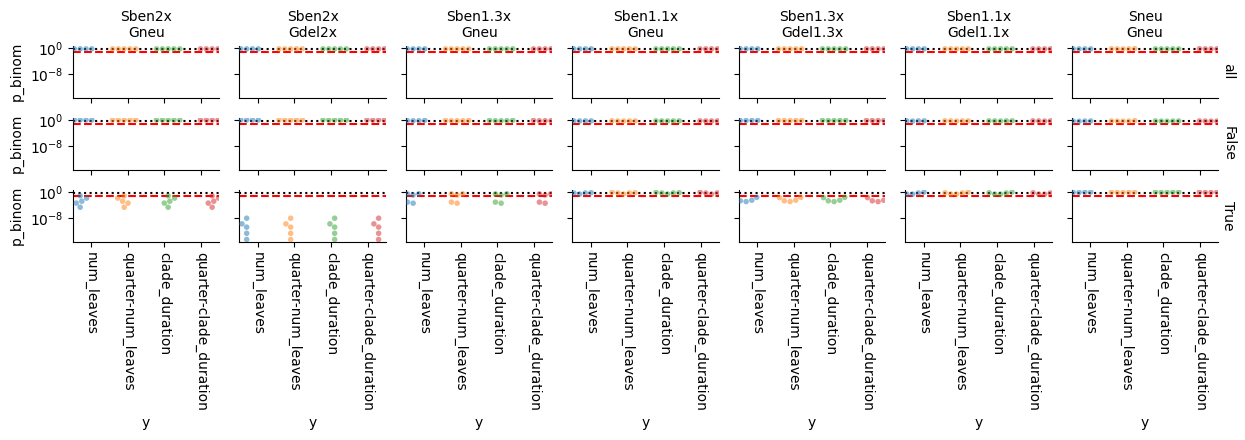

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


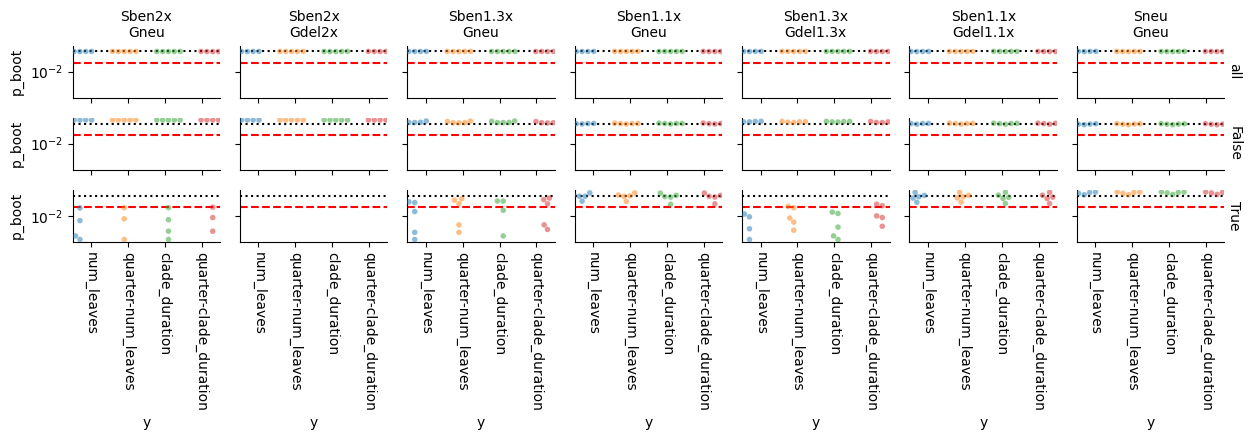

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


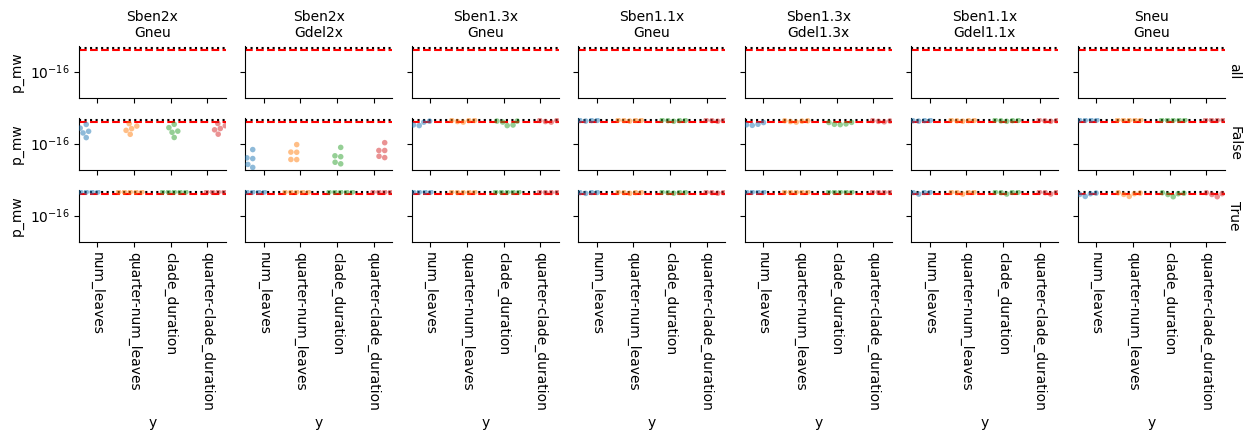

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


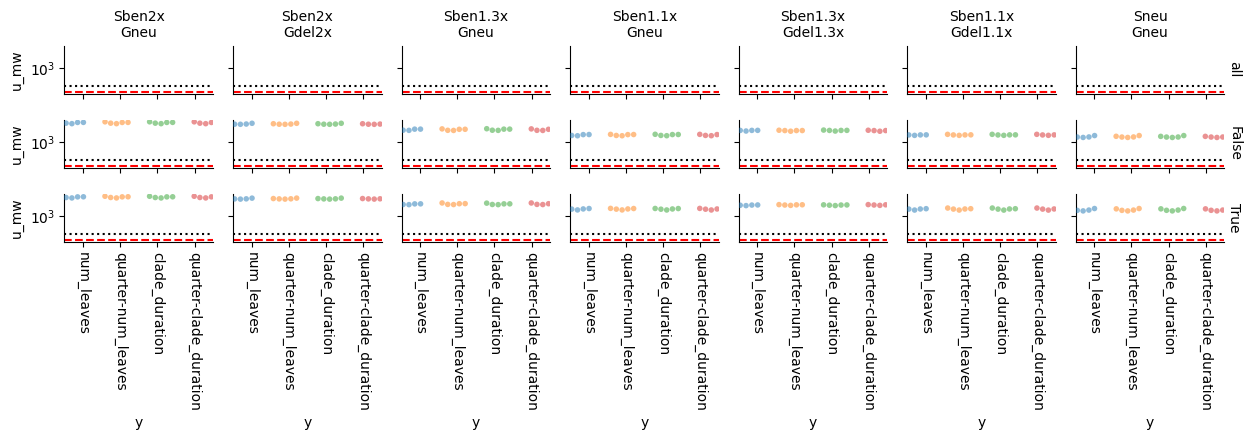

teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


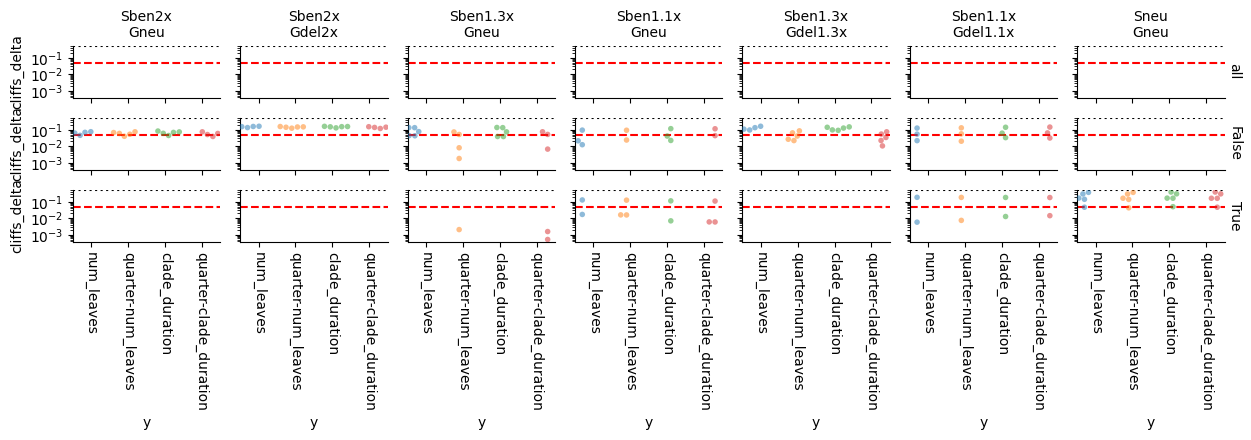

In [10]:
for y in "p_binom", "p_boot", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))
    with tp.teed(
        sns.catplot,
        data=results_df[results_df["trt_hsurf_bits"] == 0],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="y",
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=1.5,
        aspect=1.2,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("log")
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-90)

        teed.tight_layout()
